In [3]:
import warnings
from sys import warnoptions
from os import environ
if not warnoptions:
    warnings.simplefilter("ignore")
    environ["PYTHONWARNINGS"] = "ignore"
import sys
sys.path.append('..')
from src.embedders.UMAP import _ump_trans
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from src.utils.plot_activities import *

In [4]:
#!pip install plotly

In [5]:
df = pd.read_csv('../results/datacorr_6m6y18mMw1w24_processed_20230115.csv', index_col = 0)

In [6]:
df.ABCno[df.TPn=='6m'].nunique()

602

In [7]:
#Xnames = df.filter(regex='X -').columns
#df.drop(Xnames, axis=1, inplace=True)

In [8]:
cort = df.filter(regex = 'orti')
cort.columns

Index(['cortisol_Corticosteroids_Lipid', 'cortisone_Corticosteroids_Lipid'], dtype='object')

<Axes: xlabel='cortisol_Corticosteroids_Lipid', ylabel='cortisone_Corticosteroids_Lipid'>

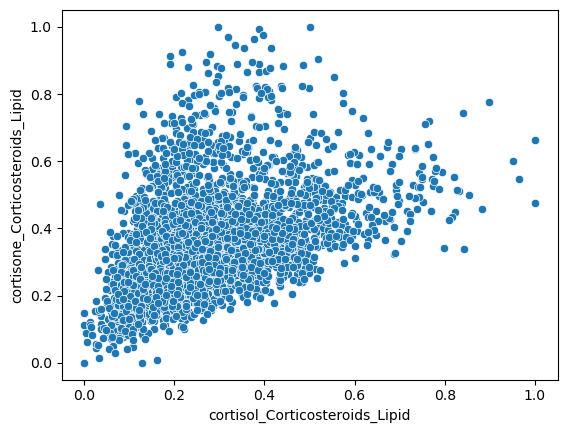

In [9]:
import seaborn as sns
sns.scatterplot(data = cort, x = 'cortisol_Corticosteroids_Lipid', y = 'cortisone_Corticosteroids_Lipid')

# Teo part


def mask_ids(index):
    #this function 
    unique_ids = set([idx.split('_')[0] for idx in index])
    mask_dict = {original_id: masked_id for original_id, masked_id in zip(unique_ids, range(1, len(unique_ids)+1))}
    
    new_index = [f"{mask_dict[idx.split('_')[0]]}_{idx.split('_')[1]}" for idx in index]
    
    return new_index
newdf = df.copy()
newdf.index = mask_ids(df.index)

newdf.drop(['TPn', 'ABCno'], axis=1, inplace=True)
newdf.columns = pd.RangeIndex(newdf.columns.size)
newdf.columns = [f'c_{i}' for i in newdf.columns]

newdf.head(2).T

newdf.to_csv('../results/teo_podaci.csv')

# continue

In [10]:
df.filter(regex='Xeno').T.head()

,2001_6m,2001_6y,2002_6m,2003_6m,2003_6y,2005_6m,2005_6y,2006_6m,2006_6y,2007_6m,...,2280_Mor w1,2141_Mor w1,2077_Mor w1,2353_Mor w1,2631_Mor w1,2641_Mor w1,2417_Mor w1,2535_Mor w1,2538_Mor w1,2471_Mor w1
tartarate_Food Component/Plant_Xenobiotics,0.000000,0.000000,0.009404,0.008946,0.321958,0.000000,0.020464,0.003107,0.024596,0.000000,...,0.000000,0.007848,0.000000,0.027040,0.013022,0.210599,0.000000,0.004711,0.000000,0.015340
3-phenylpropionate (hydrocinnamate)_Benzoate Metabolism_Xenobiotics,0.000000,0.069455,0.000000,0.000000,0.000000,0.000000,0.219839,0.010391,0.034853,0.000000,...,0.041047,0.088795,0.148062,0.151116,0.036720,0.086493,0.022531,0.000000,0.034730,0.129736
hippurate_Benzoate Metabolism_Xenobiotics,0.035548,0.018733,0.499135,0.007133,0.010204,0.010225,0.062421,0.016609,0.021998,0.015875,...,0.032294,0.083890,0.078154,0.208959,0.137075,0.130373,0.027020,0.056960,0.051818,0.085946
quinate_Food Component/Plant_Xenobiotics,0.030632,0.018881,0.139755,0.002743,0.008977,0.070093,0.020542,0.004619,0.025609,0.346617,...,0.146848,0.014081,0.021988,0.011083,0.084059,0.103517,0.002842,0.384510,0.002570,0.345302
theobromine_Xanthine Metabolism_Xenobiotics,0.002898,0.142851,0.028969,0.002155,0.028730,0.004462,0.000809,0.002216,0.069684,0.001325,...,0.016762,0.106777,0.076918,0.128914,0.280288,0.015517,0.165042,0.114030,0.364238,0.160635


In [11]:
df.isnull().sum().sort_values()

linoleate (18:2n6)_Long Chain Polyunsaturated Fatty Acid (n3 and n6)_Lipid        0
1-lignoceroyl-GPC (24:0)_Lysophospholipid_Lipid                                   0
X - 23739_NA_NA                                                                   0
alpha-ketobutyrate_Methionine, Cysteine, SAM and Taurine Metabolism_Amino Acid    0
X - 23782_NA_NA                                                                   0
                                                                                 ..
deoxycarnitine_Carnitine Metabolism_Lipid                                         0
N6-acetyllysine_Lysine Metabolism_Amino Acid                                      0
octadecanedioate (C18)_Fatty Acid, Dicarboxylate_Lipid                            0
p-cresol sulfate_Benzoate Metabolism_Xenobiotics                                  0
ABCno                                                                             0
Length: 681, dtype: int64

In [12]:
list_of_ones = df.ABCno.value_counts()[df.ABCno.value_counts()==1].index.tolist()
list_of_ones[0]

2116

In [13]:
df.drop(df[df.ABCno.isin(list_of_ones)].index, axis=0, inplace=True)

In [14]:
df.shape

(3088, 681)

# ML

In [15]:
my_list = df.columns[:-2]
print(len(sorted(my_list)))
num_rows = len(my_list) // 4 + (1 if len(my_list) % 4 else 0)

# Reshape the list into an array of the desired shape, filling missing values with NaN
array_reshaped = np.resize(my_list, (num_rows, 4))

# Convert the array into a DataFrame
dfa = pd.DataFrame(array_reshaped, columns=['Column1', 'Column2', 'Column3', 'Column4'])

# Replace zeros with NaN if the list size is not a multiple of 4
# This step ensures that placeholders are treated as missing values
dfa.replace({0: np.nan}, inplace=True)

dfa.to_csv('../results/all_metabolites.csv')

679


# split metabolites for another game

In [33]:
df.TPn.unique()

array(['6m', '6y', '18mth', 'Mor w1', 'Mor w24'], dtype=object)

In [37]:
df6m = df[df.TPn == '6y']

df6m.index  = df6m.ABCno
df6m.drop(['TPn','ABCno' ], axis=1, inplace=True)
df6m.to_csv('../data/metabolites_6y_for_ml.csv')

In [38]:
df6m.sort_index()

,linoleate (18:2n6)_Long Chain Polyunsaturated Fatty Acid (n3 and n6)_Lipid,"allantoin_Purine Metabolism, (Hypo)Xanthine/Inosine containing_Nucleotide",arachidonate (20:4n6)_Long Chain Polyunsaturated Fatty Acid (n3 and n6)_Lipid,arachidate (20:0)_Long Chain Saturated Fatty Acid_Lipid,myo-inositol_Inositol Metabolism_Lipid,"isoleucine_Leucine, Isoleucine and Valine Metabolism_Amino Acid",alanine_Alanine and Aspartate Metabolism_Amino Acid,3-methoxytyrosine_Tyrosine Metabolism_Amino Acid,"beta-hydroxyisovalerate_Leucine, Isoleucine and Valine Metabolism_Amino Acid","threonine_Glycine, Serine and Threonine Metabolism_Amino Acid",...,deoxycholic acid glucuronide_Secondary Bile Acid Metabolism_Lipid,"undecenoylcarnitine (C11:1)_Fatty Acid Metabolism (Acyl Carnitine, Monounsaturated)_Lipid","branched-chain, straight-chain, or cyclopropyl 10:1 fatty acid (1)*_Partially Characterized Molecules_Partially Characterized Molecules","branched-chain, straight-chain, or cyclopropyl 10:1 fatty acid (2)*_Partially Characterized Molecules_Partially Characterized Molecules",glutamine conjugate of C6H10O2 (1)*_Partially Characterized Molecules_Partially Characterized Molecules,"branched-chain, straight-chain, or cyclopropyl 12:1 fatty acid*_Partially Characterized Molecules_Partially Characterized Molecules",vanillic acid glycine_Food Component/Plant_Xenobiotics,4-chlorobenzoic acid_Chemical_Xenobiotics,2-O-methylascorbic acid_Ascorbate and Aldarate Metabolism_Cofactors and Vitamins,phenylalanine_Phenylalanine Metabolism_Amino Acid
ABCno,,,,,,,,,,,,,,,,,,,,,
2001,0.277622,0.109696,0.074518,0.189966,0.149797,0.156982,0.359405,0.116435,0.097348,0.222036,...,0.000000,0.091716,0.155621,0.222618,0.042470,0.222492,0.003986,0.451711,0.157662,0.203090
2003,0.056347,0.173151,0.040960,0.106702,0.150506,0.292920,0.382208,0.144532,0.079084,0.331754,...,0.000000,0.000000,0.012303,0.046313,0.000000,0.016622,0.204829,0.456078,0.247312,0.458203
2005,0.038193,0.189951,0.037041,0.058512,0.186978,0.404282,0.277305,0.114636,0.201352,0.282223,...,0.070956,0.064389,0.183372,0.101302,0.000000,0.020724,0.075389,0.491097,0.360010,0.508716
2006,0.036827,0.236783,0.036426,0.048046,0.144985,0.358874,0.397000,0.148295,0.107138,0.215596,...,0.174500,0.066242,0.069601,0.151612,0.000000,0.025570,0.058111,0.481923,0.261072,0.407570
2007,0.172571,0.099468,0.081836,0.231929,0.273676,0.341254,0.293643,0.076612,0.140948,0.358526,...,0.065560,0.120552,0.088064,0.204968,0.000000,0.072333,0.018914,0.499136,0.409204,0.426730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,0.058927,0.172693,0.022667,0.099481,0.117589,0.248375,0.318288,0.051679,0.070479,0.325731,...,0.067397,0.031172,0.109134,0.164750,0.000000,0.046888,0.036598,0.449723,0.078233,0.323166
2799,0.153140,0.189658,0.116199,0.137494,0.000000,0.375012,0.160673,0.074663,0.168080,0.215290,...,0.032709,0.319655,0.297484,0.272236,0.037553,0.390547,0.016588,0.522651,0.195073,0.384176
2800,0.043896,0.206146,0.053079,0.029255,0.174207,0.237265,0.336318,0.076325,0.159939,0.366838,...,0.042084,0.129526,0.233672,0.273751,0.000000,0.140022,0.053624,0.498941,0.038149,0.353534


In [16]:
#df_all = pd.read_csv('../data/datacorr_6m6y18mMw1w24_final.csv', sep=';')
restlist = list(set(df_all.columns[6:]).symmetric_difference(set(my_list)))
print(len(sorted(restlist)))
num_rows1 = len(restlist) // 4 + (1 if len(restlist) % 4 else 0)

# Reshape the list into an array of the desired shape, filling missing values with NaN
array_reshaped1 = np.resize(restlist, (num_rows1, 4))

# Convert the array into a DataFrame
dfa1 = pd.DataFrame(array_reshaped1, columns=['Column1', 'Column2', 'Column3', 'Column4'])

# Replace zeros with NaN if the list size is not a multiple of 4
# This step ensures that placeholders are treated as missing values
dfa1.replace({0: np.nan}, inplace=True)

dfa1.to_csv('../results/rest_metabolites.csv')

NameError: name 'df_all' is not defined

In [17]:
from src.clasif import *

In [18]:
def get_features(model, x, y, t=0, n=None):
    from sklearn.inspection import permutation_importance
    r = permutation_importance(model, x, y,
                               n_repeats=3,
                               random_state=0, n_jobs=-1)
    weights = pd.Series(r['importances_mean'], index=x.columns). \
        sort_values(ascending=False)
    if n is not None:
        return weights.head(n).index.tolist()
    else:
        return weights[weights > t].index.tolist()
    

# old code

In [19]:

def test_predict(x,y):
    
    auc_scorer = make_scorer(matthews_corrcoef)
    cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

    param_grid_rf = {
        'n_estimators': [200],
        'max_features': [.5,.6],
        'max_depth': [5, 7],
        'criterion': ['entropy'],
        'n_jobs': [-1],
        'min_samples_split': [4,6],
        'class_weight': ['balanced'],
        'random_state': [42],
    }
    
    param_grid_lr = {
        #'penalty' : ["elasticnet"],
        'l1_ratio': [1E-6, 1E-5, 1E-4, 5E-4, 1E-3, 5E-3, 1E-2],
        'C':  [1E-4, 1E-3, 1E-2, 1E-1, 1, 1E1, 1E2, 5E2, 1E3],
        'n_jobs': [-1],
        #'solver' : ['saga'],
        'class_weight': ['balanced'],
        'random_state': [42],
    }
    #ExtraTreesClassifier()
    #model = GridSearchCV(estimator=LogisticRegression(),
    #                     param_grid=param_grid_lr, cv=cv,
    #                     scoring=auc_scorer, n_jobs=-1)
    
    model = GridSearchCV(estimator=RandomForestClassifier(),
                         param_grid=param_grid_rf, cv=cv,
                         scoring=auc_scorer, n_jobs=-1)


    model.fit(x,y)
    sel_feat = get_features(model, x,y , t=-0.1)
    

    model.fit(x[sel_feat], y)
    sel_feat2 = get_features(model, x[sel_feat], y, t=-0.05)

    model.fit(x[sel_feat2], y)
    sel_feat3 = get_features(model, x[sel_feat2], y, t=0)
    print(model.best_params_)
    
    model.fit(x[sel_feat3], y)
    sel_feat4 = get_features(model, x[sel_feat3], y, t=0)
    print(model.best_params_)

    model.fit(x[sel_feat4], y)
    features = get_feature_series(model, x[sel_feat4], y).round(3)

    yhat = model.predict_proba(x[sel_feat4])
    

    return yhat

In [17]:
def gendyads(df, tpns = ['6m','Mor w24']):
    
    df_local_1 = df[df.TPn.isin(tpns)].copy()    
    vc = df_local_1.ABCno.value_counts()
    #select thise the one ABC count
    kick_one_part = vc[vc==1].index.tolist()
    kicking_index = df_local_1[df_local_1.ABCno.isin(kick_one_part)].index.tolist()
    print(len(kick_one_part), len(kicking_index))
    # drop the indexers
    df_local = df_local_1.drop(kicking_index, axis=0)
    print(df_local.shape, df_local_1.shape)
    
    #set mothers and child DF
    df_mothers = df_local[df_local.TPn == 'Mor w24'].drop('TPn', axis=1)
    df_children = df_local[df_local.TPn == '6m'].drop('TPn', axis=1)
    
    #mix up moms, reset index, assign new, create a 2nd df too
    random_abc_moms_1 = df_mothers['ABCno'].sample(frac=1, random_state=42).reset_index(drop=True)
    random_abc_moms_1.index = df_mothers.index
    random_abc_moms_2 = df_mothers['ABCno'].sample(frac=1, random_state=0).reset_index(drop=True)
    random_abc_moms_2.index = df_mothers.index


    random_moms_1 = df_mothers.copy()
    random_moms_1['ABCno'] = random_abc_moms_1
    random_moms_2 = df_mothers.copy()
    random_moms_2['ABCno'] = random_abc_moms_2
    
    #=============================

    #true dyads are then groupped by ABC
    true_dyads = df_local.drop(['ABCno'], axis=1).groupby(df_local.ABCno).std()
    #dyad value is 1
    true_dyads['dyad'] = 1
        
    
    #===========================
    
    # concatenate moms with children
    random_dyad_v1 = pd.concat([df_children, random_moms_1], axis=0)
    random_dyad_std_v1 = random_dyad_v1.drop(['ABCno'], axis=1).groupby(random_dyad_v1['ABCno']).std()
    #dyad value is 0
    random_dyad_std_v1['dyad'] = 0

    #2nd df too
    random_dyad_v2 = pd.concat([df_children, random_moms_2], axis=0)
    random_dyad_std_v2 = random_dyad_v2.drop(['ABCno'], axis=1).groupby(random_dyad_v2['ABCno']).std()
    random_dyad_std_v2['dyad'] = 0
    
    #assign indices as nd - nondyads
    random_dyad_std_v1.index = [f'nd1_{i}' for i in random_dyad_std_v1.index]
    random_dyad_std_v2.index = [f'nd2_{i}' for i in random_dyad_std_v2.index]
    
   
    #===========================
    
    random_merged = pd.concat([random_dyad_std_v1, 
                           random_dyad_std_v2], axis=0)
    #part is randomly removed
    remove_n = int(len(random_merged)*.5)
    drop_indices = np.random.choice(random_merged.index, remove_n, replace=False)
    random_subset = random_merged.drop(drop_indices)

    merged_df = pd.concat([random_subset, 
                           true_dyads], axis=0)
    
    #print(merged_df.shape, true_dyads.shape, random_dyad_std_v1.shape, random_dyad_std_v2.shape)
    #print(merged_df.T.isnull().sum().sort_values())
          
    merged_df.dropna(thresh=int(merged_df.shape[1]*.9), axis=0, inplace=True)
    #print(merged_df.T.isnull().sum().sort_values())
    merged_df.fillna(merged_df.median(), inplace=True)
    #print(merged_df.shape)
    return merged_df


In [18]:
data = gendyads(df)

105 105
(1182, 681) (1287, 681)


NameError: name 'data' is not defined

In [20]:
x = data.drop('dyad', axis=1)
y = data.dyad    

#yh = test_predict(x,y)

In [21]:
y.value_counts()

0    591
1    591
Name: dyad, dtype: int64

In [22]:
yh = pd.DataFrame(yh, index=x.index, columns = ['y0','y1'])
yh

NameError: name 'yh' is not defined

In [ ]:
yh = yh[yh.index.isin(df.ABCno)]

In [ ]:
yh.y1.hist(bins=100)

In [ ]:
yh.y1.apply(lambda x: 1 if x > 0.55 else 0).value_counts()

In [ ]:
def get_features(model, x, y, t=0, n=None):
    from sklearn.inspection import permutation_importance
    r = permutation_importance(model, x, y,
                               n_repeats=5,
                               random_state=0, n_jobs=-1)
    weights = pd.Series(r['importances_mean'], index=x.columns). \
        sort_values(ascending=False)
    if n is not None:
        return weights.head(n).index.tolist()
    else:
        return weights[weights > t].index.tolist()

In [27]:
def protoclf(x,y):
    from sklearn.inspection import permutation_importance
    
    X_train, X_test, y_train, y_test = train_test_split(x, y,
                                                        test_size=0.7,
                                                        random_state=42,
                                                        stratify=y,
                                                        shuffle=True)

    scorers = {
        'mcc': make_scorer(matthews_corrcoef),
        'accuracy': 'accuracy',
        'roc_auc': 'roc_auc'}
    

    param_grid_rf = {
        'n_estimators': [300],
        'max_features' : [.3, .4, .5],
        'max_depth': [6, 7, 8],
        'criterion': ['entropy'],
        'n_jobs': [-1],
         'min_samples_split': [4, 5],
        #class_weight': ['balanced'],
        'random_state': [42]}
    # run 1
    
    cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
    model = GridSearchCV(estimator=ExtraTreesClassifier(),
                         param_grid=param_grid_rf, cv=cv,
                         scoring=scorers, refit='mcc', n_jobs=-1)

    model.fit(X_train, y_train)
    sel_feat = get_features(model, X_train, y_train, t=-0.1)
    print(model.best_params_)
    
    # run 2
    cv = StratifiedKFold(n_splits=5, random_state=41, shuffle=True)
    model = GridSearchCV(estimator=ExtraTreesClassifier(),
                         param_grid=param_grid_rf, cv=cv,
                         scoring=scorers, refit='mcc', n_jobs=-1)
    
    model.fit(X_train[sel_feat], y_train)
    sel_feat2 = get_features(model, X_train[sel_feat], y_train, t=-0.05)
    print(model.best_params_)
    
    # run 3
    cv = StratifiedKFold(n_splits=5, random_state=40, shuffle=True)
    model = GridSearchCV(estimator=ExtraTreesClassifier(),
                         param_grid=param_grid_rf, cv=cv,
                         scoring=scorers, refit='mcc', n_jobs=-1)
    
    model.fit(X_train[sel_feat2], y_train)
    sel_feat3 = get_features(model, X_train[sel_feat2], y_train, t=-0.05)
    print(model.best_params_)
    
    # run 4
    cv = StratifiedKFold(n_splits=5, random_state=39, shuffle=True)
    model = GridSearchCV(estimator=ExtraTreesClassifier(),
                         param_grid=param_grid_rf, cv=cv,
                         scoring=scorers, refit='mcc', n_jobs=-1)
    model.fit(X_train[sel_feat3], y_train)
    sel_feat4 = get_features(model, X_train[sel_feat3], y_train, t=0.000)
    print(model.best_params_)
    
    # final run
    cv = StratifiedKFold(n_splits=5, random_state=38, shuffle=True)
    model = GridSearchCV(estimator=ExtraTreesClassifier(),
                         param_grid=param_grid_rf, cv=cv,
                         scoring=scorers, refit='mcc', n_jobs=-1)
    model.fit(X_train[sel_feat4], y_train)
    print(model.best_params_)
    
    yhat = model.predict(X_test[sel_feat4])
    yhat_train = model.predict_proba(X_train[sel_feat4])[:, 1]
    yhat_prob = model.predict_proba(X_test[sel_feat4])[:, 1]
    
    #******
    y_hat_train = pd.DataFrame(yhat_train, index=X_train.index, columns=['prediction'])
    y_hat_test = pd.DataFrame(yhat_prob, index=X_test.index, columns=['prediction'])
    y_hat_train['set'] = 'train'
    y_hat_test['set'] = 'test'
    
    y_all_predicted = pd.concat([y_hat_train, y_hat_test], axis=0)
    #******
    # get features
    
    r = permutation_importance(model, X_train[sel_feat4], y_train,
                               n_repeats=3,
                               random_state=0, n_jobs=-1)
    features = pd.Series(r['importances_mean'], index=sel_feat4). \
        sort_values(ascending=False)
    
    from sklearn.metrics import roc_auc_score
    mcc = matthews_corrcoef(y_test, yhat)
    accuracy = accuracy_score(y_test, yhat)
    auc = roc_auc_score(y_test, yhat_prob)

    print(f"Last model's MCC CV result: {model.cv_results_['mean_test_mcc'][model.best_index_]}")
    print(f"Last model's Accuracy CV result: {model.cv_results_['mean_test_accuracy'][model.best_index_]}")
    print(f"Last model's AUC CV result: {model.cv_results_['mean_test_roc_auc'][model.best_index_]}")
    
    
    print(f"Last model's MCC Test result: {mcc}")
    print(f"Last model's Accuracy Test result: {accuracy}")
    print(f"Last model's AUC Tes result: {auc}")

    #****** added y_all
    return mcc, accuracy, auc, features, yhat_prob, y_all_predicted


In [28]:
#one_res = {'mcc':mcc, 'acc':acc, 'auc':auc, 'feats':feats}
mcc, acc, auc, feats, yh1, y_all = protoclf(x,y)
print(mcc, acc, auc)

{'criterion': 'entropy', 'max_depth': 6, 'max_features': 0.4, 'min_samples_split': 5, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
{'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.3, 'min_samples_split': 5, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
{'criterion': 'entropy', 'max_depth': 7, 'max_features': 0.4, 'min_samples_split': 5, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
{'criterion': 'entropy', 'max_depth': 6, 'max_features': 0.5, 'min_samples_split': 5, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
{'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.3, 'min_samples_split': 4, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
Last model's MCC CV result: 0.4523320889623463
Last model's Accuracy CV result: 0.7258752515090544
Last model's AUC CV result: 0.7682131519274377
Last model's MCC Test result: 0.27541374397702556
Last model's Accuracy Test result: 0.6376811594202898
Last model's AUC Tes result: 0.67442355714252

In [286]:
y_all[y_all.index.isin(df.ABCno)].to_csv('transmission_factors.csv')

<AxesSubplot:>

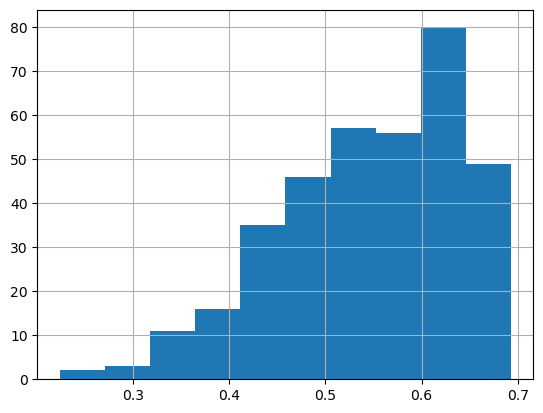

In [287]:
y_all[y_all.index.isin(df.ABCno)].prediction[y_all['set']=='test'].hist()

<AxesSubplot:>

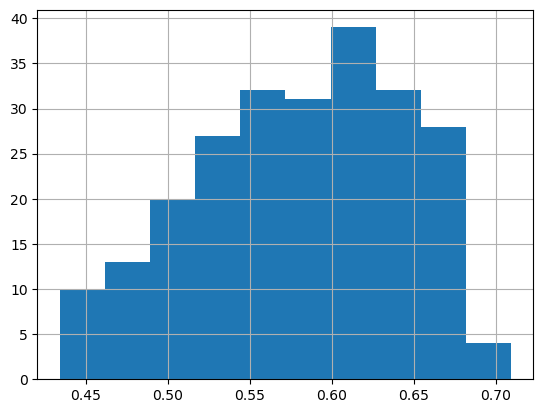

In [288]:
y_all[y_all.index.isin(df.ABCno)].prediction[y_all['set']=='train'].hist()

In [269]:
pd.DataFrame(feats, columns=['Feature']).round(3)

,Feature
X - 11308_NA_NA,0.101
"N6,N6-dimethyllysine_Lysine Metabolism_Amino Acid",0.101
X - 12798_NA_NA,0.095
X - 24970_NA_NA,0.088
perfluorooctanoate (PFOA)_Chemical_Xenobiotics,0.075
perfluorooctanesulfonate (PFOS)_Chemical_Xenobiotics,0.070
"hydroxy-CMPF*_Fatty Acid, Dicarboxylate_Lipid",0.066
"dimethylglycine_Glycine, Serine and Threonine Metabolism_Amino Acid",0.056
N-methylpipecolate_Bacterial/Fungal_Xenobiotics,0.053


In [272]:
feature_importance_dict = {
    "X - 11308_NA_NA": 0.101,
    "N6,N6-dimethyllysine_Lysine Metabolism_Amino Acid": 0.101,
    "X - 12798_NA_NA": 0.095,
    "X - 24970_NA_NA": 0.088,
    "perfluorooctanoate (PFOA)_Chemical_Xenobiotics": 0.075,
    "perfluorooctanesulfonate (PFOS)_Chemical_Xenobiotics": 0.070,
    "hydroxy-CMPF*_Fatty Acid, Dicarboxylate_Lipid": 0.066,
    "dimethylglycine_Glycine, Serine and Threonine Metabolism_Amino Acid": 0.056,
    "N-methylpipecolate_Bacterial/Fungal_Xenobiotics": 0.053
}
# Convert to DataFrame
dfa = pd.DataFrame(list(feature_importance_dict.items()), columns=['Feature', 'Importance'])

# Split the 'Feature' column based on underscores
dfa[['Metabolite', 'Pathway', 'Group']] = dfa['Feature'].str.split('_', expand=True)

# Drop the original 'Feature' column
dfa = dfa.drop(columns=['Feature'])

dfa

,Importance,Metabolite,Pathway,Group
0,0.101,X - 11308,NA,NA
1,0.101,"N6,N6-dimethyllysine",Lysine Metabolism,Amino Acid
2,0.095,X - 12798,NA,NA
3,0.088,X - 24970,NA,NA
4,0.075,perfluorooctanoate (PFOA),Chemical,Xenobiotics
5,0.070,perfluorooctanesulfonate (PFOS),Chemical,Xenobiotics
6,0.066,hydroxy-CMPF*,"Fatty Acid, Dicarboxylate",Lipid
7,0.056,dimethylglycine,"Glycine, Serine and Threonine Metabolism",Amino Acid
8,0.053,N-methylpipecolate,Bacterial/Fungal,Xenobiotics


In [259]:
X_train, X_test, y_train, y_test = train_test_split(x, y,
                                                        test_size=0.6,
                                                        random_state=42,
                                                        stratify=y,
                                                        shuffle=True)


In [260]:
yhh = pd.DataFrame(yh1, index=y_test.index)
yhh = yhh[yhh.index.isin(df.ABCno)]
yhh

,0
2333,0.606578
2155,0.505312
2066,0.632641
2526,0.653432
2353,0.507285
...,...
2239,0.643713
2302,0.587152
2729,0.523445
2625,0.563198


In [262]:
yhh.to_csv('../data/yh.csv')

In [268]:
ybinh = yhh.applymap(lambda x: 1 if x > .50 else 0)
ybinh.value_counts()

1    247
0    108
dtype: int64